# Clustering dan Reduksi Dimensi — Kelompok 3

**Mata Kuliah:** Machine Learning (Kelas C) — Bapak Adi Purnawan

**Judul:** Prediksi Risiko Stroke Menggunakan Logistic Regression dan Gradient Boosting dengan Interpretasi Explainable AI

**Anggota:** Deliana Br Manalu (2305551036) · Ravi Arnan Irianto (2305551076) · Ezza Putra Wibawa (2305551144) · Devin (2305551173)

---

Notebook ini menutup **Bab 8** (K-Means, Hierarchical, DBSCAN) dan **Bab 9** (PCA, LDA).

Bedanya dengan notebook `05`: di sini label `stroke` **tidak dipakai untuk melatih**.
Kami biarkan algoritma mengelompokkan pasien berdasarkan karakteristiknya saja, baru
setelah itu kami intip berapa proporsi penderita stroke di tiap kelompok. Kalau
kelompok yang terbentuk ternyata punya proporsi stroke yang berbeda-beda, berarti
pola risiko memang ada di dalam data — tanpa perlu diberi tahu jawabannya.


## 1. Persiapan

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.metrics import silhouette_score, roc_auc_score, recall_score
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
SEED = 42


def muat_data_stroke(seed=SEED):
    """Preprocessing identik dengan notebook 04. Sengaja disalin ulang supaya
    notebook ini tetap bisa dijalankan sendiri di Colab."""
    url = ("https://raw.githubusercontent.com/ray-project/raydp/master/"
           "tutorials/dataset/healthcare-dataset-stroke-data.csv")
    fitur_imp = ["age", "hypertension", "heart_disease", "avg_glucose_level",
                 "gender", "ever_married", "work_type", "Residence_type", "smoking_status"]

    d = pd.read_csv(url).drop(columns=["id"])
    d = d[d.gender != "Other"].copy()

    kosong = d.bmi.isna()
    if kosong.any():
        latih = d[~kosong]
        X_l = pd.get_dummies(latih[fitur_imp], drop_first=True)
        m = make_pipeline(StandardScaler(), Ridge(alpha=1.0, random_state=seed)).fit(X_l, latih.bmi)
        X_k = pd.get_dummies(d[kosong][fitur_imp], drop_first=True).reindex(
            columns=X_l.columns, fill_value=0)
        d.loc[kosong, "bmi"] = m.predict(X_k)

    X = pd.get_dummies(d.drop(columns=["stroke"]), drop_first=True)
    return X, d.stroke, d


X, y, asli = muat_data_stroke()
Xs = StandardScaler().fit_transform(X)      # clustering wajib pakai data terskala
print("Bentuk data:", X.shape)
print(f"Label stroke DISIMPAN, tidak dipakai melatih: {y.sum()} kasus ({y.mean()*100:.2f}%)")

Bentuk data: (5109, 15)
Label stroke DISIMPAN, tidak dipakai melatih: 249 kasus (4.87%)


## 2. K-Means (Bab 8)

Dua cara menentukan jumlah kelompok yang pantas: metode siku (elbow) dan skor silhouette.

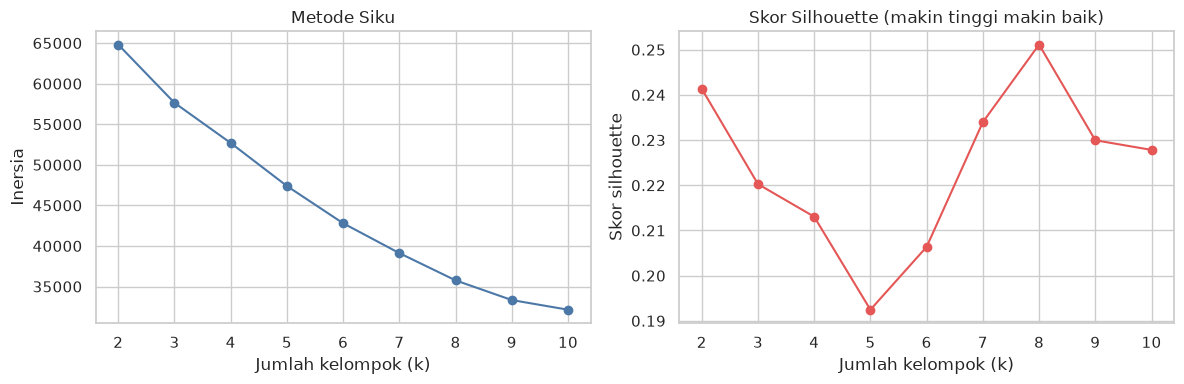

Silhouette tertinggi pada k = 8 (0.251)


In [2]:
inersia, silhouette, rentang = [], [], range(2, 11)

for k in rentang:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10).fit(Xs)
    inersia.append(km.inertia_)
    silhouette.append(silhouette_score(Xs, km.labels_, sample_size=2000, random_state=SEED))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(rentang, inersia, "o-", color="#4C78A8")
ax[0].set_xlabel("Jumlah kelompok (k)"); ax[0].set_ylabel("Inersia")
ax[0].set_title("Metode Siku")

ax[1].plot(rentang, silhouette, "o-", color="#E45756")
ax[1].set_xlabel("Jumlah kelompok (k)"); ax[1].set_ylabel("Skor silhouette")
ax[1].set_title("Skor Silhouette (makin tinggi makin baik)")

plt.tight_layout(); plt.show()

terbaik = rentang[int(np.argmax(silhouette))]
print(f"Silhouette tertinggi pada k = {terbaik} ({max(silhouette):.3f})")

### Profil tiap kelompok

Di sinilah label `stroke` baru dipakai — bukan untuk melatih, tetapi untuk memeriksa
apakah kelompok yang terbentuk ternyata berbeda risikonya.

In [3]:
# Silhouette tertinggi ada di k=8, bukan k=4. Kami tetap memilih k=4 secara sadar:
# selisih silhouette-nya kecil, sementara 8 kelompok terlalu banyak untuk
# ditafsirkan sebagai profil pasien yang bermakna. Ini pertukaran antara
# ukuran statistik dan kegunaan praktis, dan kami memilih yang kedua.
K = 4
km = KMeans(n_clusters=K, random_state=SEED, n_init=10).fit(Xs)
asli["kelompok"] = km.labels_

profil = asli.groupby("kelompok").agg(
    jumlah=("stroke", "size"),
    kasus_stroke=("stroke", "sum"),
    persen_stroke=("stroke", lambda s: round(s.mean() * 100, 2)),
    rata_usia=("age", lambda s: round(s.mean(), 1)),
    rata_bmi=("bmi", lambda s: round(s.mean(), 1)),
    rata_glukosa=("avg_glucose_level", lambda s: round(s.mean(), 1)),
    persen_hipertensi=("hypertension", lambda s: round(s.mean() * 100, 1)),
    persen_sakit_jantung=("heart_disease", lambda s: round(s.mean() * 100, 1)),
)
profil

,jumlah,kasus_stroke,persen_stroke,rata_usia,rata_bmi,rata_glukosa,persen_hipertensi,persen_sakit_jantung
kelompok,,,,,,,,
0,2914,147,5.04,46.7,30.3,107.1,9.5,5.1
1,710,2,0.28,7.1,20.2,94.4,0.0,0.1
2,663,34,5.13,45.3,30.6,106.0,11.3,6.5
3,822,66,8.03,60.3,30.2,112.8,17.9,10.2


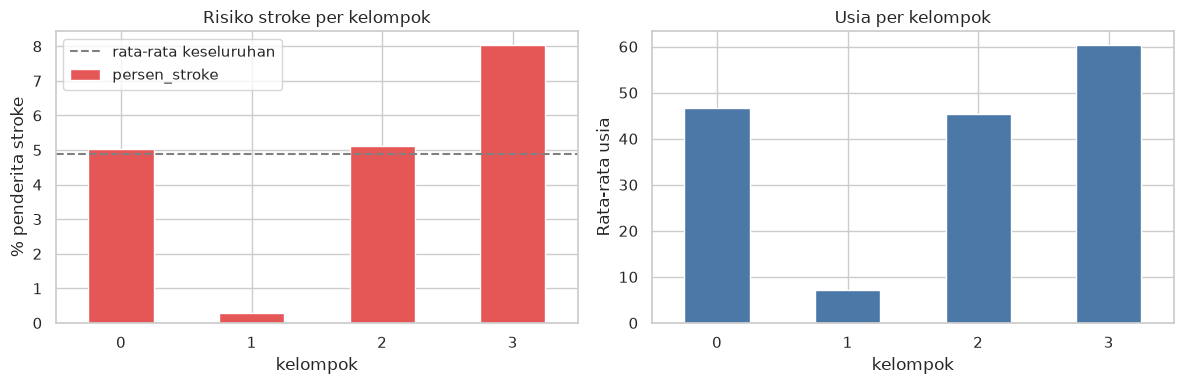

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
profil.persen_stroke.plot(kind="bar", ax=ax[0], color="#E45756")
ax[0].axhline(y.mean() * 100, ls="--", color="grey", label="rata-rata keseluruhan")
ax[0].set_ylabel("% penderita stroke"); ax[0].set_title("Risiko stroke per kelompok")
ax[0].legend(); ax[0].tick_params(axis="x", rotation=0)

profil.rata_usia.plot(kind="bar", ax=ax[1], color="#4C78A8")
ax[1].set_ylabel("Rata-rata usia"); ax[1].set_title("Usia per kelompok")
ax[1].tick_params(axis="x", rotation=0)

plt.tight_layout(); plt.show()

## 3. Hierarchical Clustering (Bab 8)

Dendrogram memerlukan perhitungan jarak antar seluruh pasangan data. Pada 5.109 baris
itu berarti sekitar 13 juta pasangan — berat dan dendrogramnya pun tidak terbaca.

Karena itu kami memakai **sampel acak 800 pasien**. Ini keterbatasan yang disebutkan
apa adanya, bukan disembunyikan.

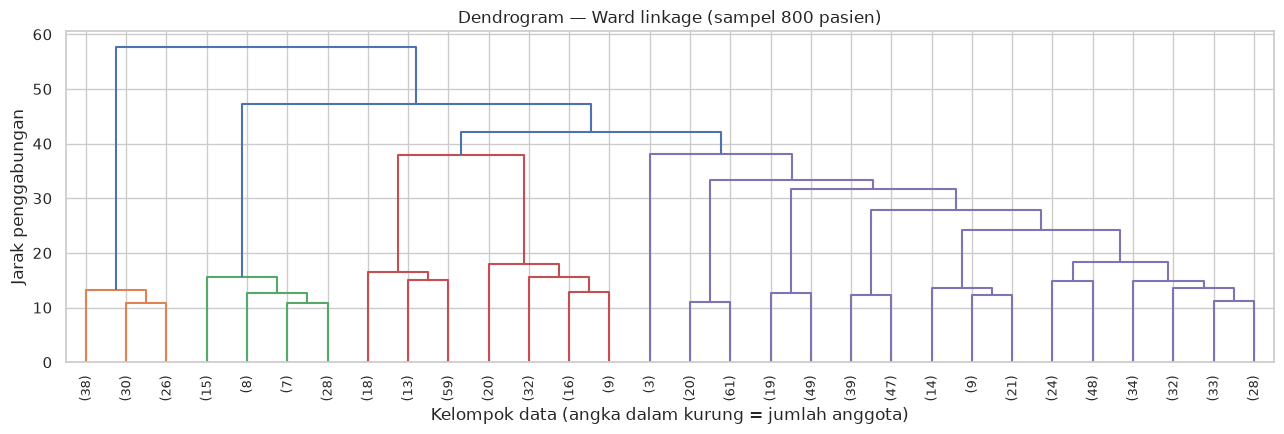

In [5]:
acak = np.random.RandomState(SEED)
indeks = acak.choice(len(Xs), size=800, replace=False)
sampel = Xs[indeks]

hubungan = linkage(sampel, method="ward")

plt.figure(figsize=(13, 4.5))
dendrogram(hubungan, truncate_mode="lastp", p=30, leaf_rotation=90, leaf_font_size=9)
plt.title("Dendrogram — Ward linkage (sampel 800 pasien)")
plt.xlabel("Kelompok data (angka dalam kurung = jumlah anggota)")
plt.ylabel("Jarak penggabungan")
plt.tight_layout(); plt.show()

In [6]:
hasil_hier = []
for k in [2, 3, 4, 5]:
    label = AgglomerativeClustering(n_clusters=k, linkage="ward").fit_predict(sampel)
    hasil_hier.append({"k": k, "silhouette": round(silhouette_score(sampel, label), 3)})

pd.DataFrame(hasil_hier)

,k,silhouette
0,2,0.203
1,3,0.232
2,4,0.211
3,5,0.220


## 4. DBSCAN (Bab 8)

DBSCAN berbeda dari dua sebelumnya: ia tidak perlu diberi tahu jumlah kelompok, dan ia
boleh menyatakan sebagian data sebagai **noise** — titik yang tidak masuk kelompok mana
pun.

Justru itu yang menarik: pasien yang ditandai noise adalah pasien dengan kombinasi
karakteristik paling tidak lazim. Layak diperiksa.

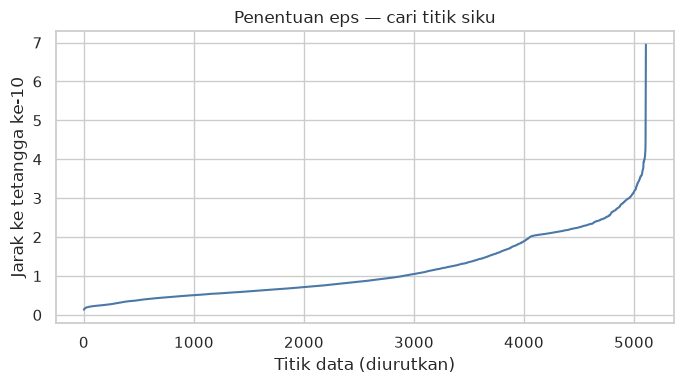

Rentang jarak: 0.13 - 6.95


In [7]:
# eps ditentukan dari grafik jarak ke tetangga ke-k, bukan ditebak
k_tetangga = 10
jarak, _ = NearestNeighbors(n_neighbors=k_tetangga).fit(Xs).kneighbors(Xs)
jarak_k = np.sort(jarak[:, -1])

plt.figure(figsize=(7, 4))
plt.plot(jarak_k, color="#4C78A8")
plt.xlabel("Titik data (diurutkan)"); plt.ylabel(f"Jarak ke tetangga ke-{k_tetangga}")
plt.title("Penentuan eps — cari titik siku")
plt.tight_layout(); plt.show()

print("Rentang jarak:", round(jarak_k.min(), 2), "-", round(jarak_k.max(), 2))

In [8]:
hasil_db = []
for eps in [1.5, 2.0, 2.5, 3.0]:
    label = DBSCAN(eps=eps, min_samples=k_tetangga).fit_predict(Xs)
    n_klaster = len(set(label)) - (1 if -1 in label else 0)
    n_noise = int((label == -1).sum())
    baris = {"eps": eps, "kelompok": n_klaster, "noise": n_noise,
             "noise %": round(100 * n_noise / len(label), 1)}
    if n_klaster > 1:
        inti = label != -1
        baris["silhouette"] = round(silhouette_score(Xs[inti], label[inti]), 3)
    hasil_db.append(baris)

pd.DataFrame(hasil_db)

,eps,kelompok,noise,noise %,silhouette
0,1.5,79,1033,20.2,0.413
1,2.0,87,767,15.0,0.389
2,2.5,21,131,2.6,0.251
3,3.0,6,44,0.9,0.213


In [9]:
# ambil konfigurasi yang menghasilkan noise dalam jumlah wajar untuk diperiksa
label_db = DBSCAN(eps=2.0, min_samples=k_tetangga).fit_predict(Xs)
asli["dbscan"] = label_db
noise = asli[asli.dbscan == -1]

print(f"Pasien ditandai noise: {len(noise)} ({len(noise)/len(asli)*100:.1f}%)")
if len(noise):
    print(f"Proporsi stroke pada noise      : {noise.stroke.mean()*100:.2f}%")
    print(f"Proporsi stroke keseluruhan     : {asli.stroke.mean()*100:.2f}%")
    print()
    print(noise[["age", "avg_glucose_level", "bmi", "hypertension",
                 "heart_disease", "stroke"]].describe().round(1).to_string())

Pasien ditandai noise: 767 (15.0%)
Proporsi stroke pada noise      : 11.34%
Proporsi stroke keseluruhan     : 4.87%

         age  avg_glucose_level    bmi  hypertension  heart_disease  stroke
count  767.0              767.0  767.0         767.0          767.0   767.0
mean    56.7              132.2   32.0           0.4            0.3     0.1
std     20.1               62.8    8.8           0.5            0.5     0.3
min      2.0               55.8   14.6           0.0            0.0     0.0
25%     45.0               80.7   26.8           0.0            0.0     0.0
50%     61.0              103.1   30.7           0.0            0.0     0.0
75%     73.0              199.6   35.2           1.0            1.0     0.0
max     82.0              271.7   97.6           1.0            1.0     1.0


## 5. PCA — Reduksi Dimensi Tanpa Label (Bab 9)

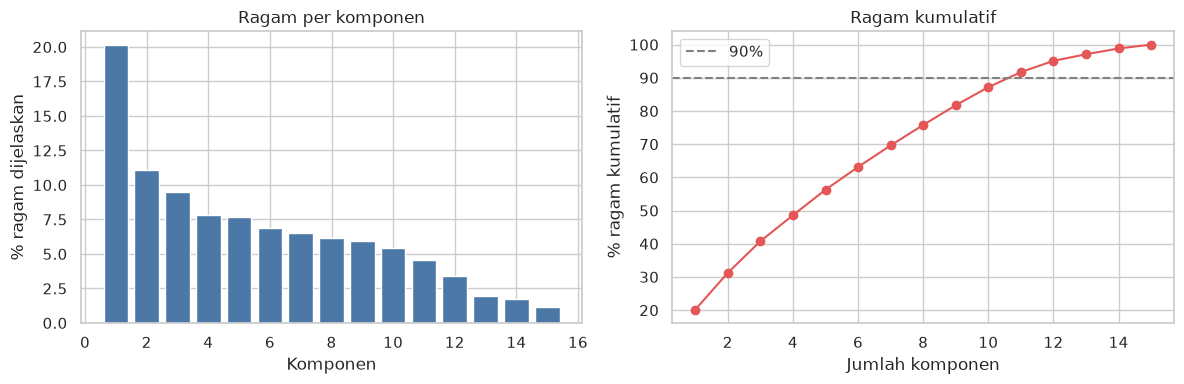

Komponen untuk mencapai 90% ragam: 11 dari 15 fitur asli
Dua komponen pertama menjelaskan  : 31.2% ragam


In [10]:
pca = PCA().fit(Xs)
kumulatif = np.cumsum(pca.explained_variance_ratio_)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].bar(range(1, len(pca.explained_variance_ratio_) + 1),
          pca.explained_variance_ratio_ * 100, color="#4C78A8")
ax[0].set_xlabel("Komponen"); ax[0].set_ylabel("% ragam dijelaskan")
ax[0].set_title("Ragam per komponen")

ax[1].plot(range(1, len(kumulatif) + 1), kumulatif * 100, "o-", color="#E45756")
ax[1].axhline(90, ls="--", color="grey", label="90%")
ax[1].set_xlabel("Jumlah komponen"); ax[1].set_ylabel("% ragam kumulatif")
ax[1].set_title("Ragam kumulatif"); ax[1].legend()

plt.tight_layout(); plt.show()

butuh90 = int(np.argmax(kumulatif >= 0.90) + 1)
print(f"Komponen untuk mencapai 90% ragam: {butuh90} dari {X.shape[1]} fitur asli")
print(f"Dua komponen pertama menjelaskan  : {kumulatif[1]*100:.1f}% ragam")

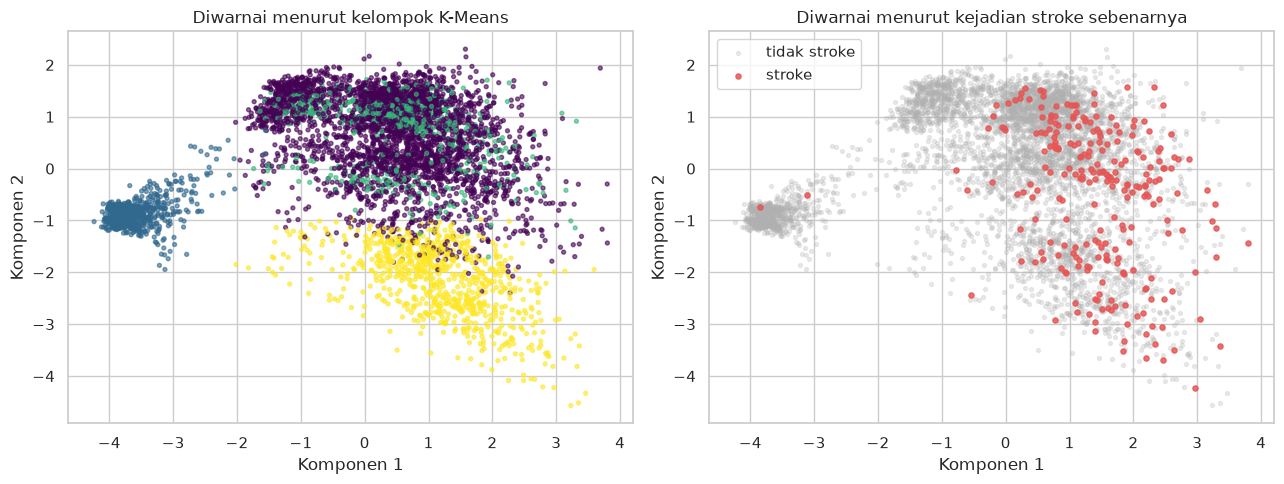

In [11]:
P2 = PCA(n_components=2, random_state=SEED).fit_transform(Xs)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].scatter(P2[:, 0], P2[:, 1], c=km.labels_, cmap="viridis", s=8, alpha=.6)
ax[0].set_title("Diwarnai menurut kelompok K-Means")

sehat = y == 0
ax[1].scatter(P2[sehat, 0], P2[sehat, 1], s=8, alpha=.25, color="#B0B0B0", label="tidak stroke")
ax[1].scatter(P2[~sehat, 0], P2[~sehat, 1], s=14, alpha=.85, color="#E45756", label="stroke")
ax[1].set_title("Diwarnai menurut kejadian stroke sebenarnya"); ax[1].legend()

for a in ax:
    a.set_xlabel("Komponen 1"); a.set_ylabel("Komponen 2")
plt.tight_layout(); plt.show()

## 6. LDA dan Perbandingannya dengan PCA (Bab 9)

**Perbedaan mendasar:** PCA mencari arah dengan ragam terbesar **tanpa melihat label**.
LDA mencari arah yang paling memisahkan **kelas yang sudah diketahui**.

Ada konsekuensi yang sering luput: LDA hanya bisa menghasilkan sebanyak-banyaknya
`jumlah_kelas − 1` komponen. Masalah kami biner, jadi **LDA hanya memberi satu dimensi** —
tidak bisa dibuat sebar dua dimensi seperti PCA.

Komponen maksimum LDA untuk 2 kelas: 1


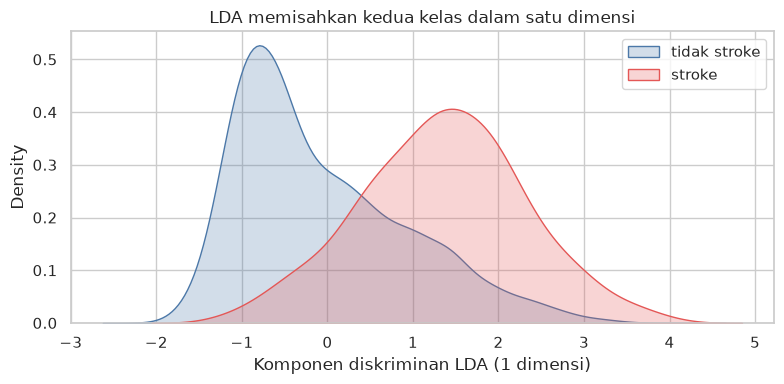

In [12]:
lda = LDA(n_components=1).fit(Xs, y)
L1 = lda.transform(Xs).ravel()

print(f"Komponen maksimum LDA untuk {y.nunique()} kelas: {y.nunique() - 1}")

plt.figure(figsize=(8, 4))
sns.kdeplot(L1[y == 0], fill=True, label="tidak stroke", color="#4C78A8")
sns.kdeplot(L1[y == 1], fill=True, label="stroke", color="#E45756")
plt.xlabel("Komponen diskriminan LDA (1 dimensi)")
plt.title("LDA memisahkan kedua kelas dalam satu dimensi")
plt.legend(); plt.tight_layout(); plt.show()

### Mana yang lebih berguna untuk klasifikasi?

Dibandingkan secara adil: Logistic Regression yang sama, hanya masukannya berbeda.

In [13]:
cv = StratifiedKFold(5, shuffle=True, random_state=SEED)
klas = LogisticRegression(max_iter=5000, class_weight="balanced", random_state=SEED)

banding = []
for nama, fitur in [
    (f"Semua fitur asli ({X.shape[1]})", Xs),
    (f"PCA {butuh90} komponen (90% ragam)", PCA(n_components=butuh90, random_state=SEED).fit_transform(Xs)),
    ("PCA 2 komponen", P2),
    ("LDA 1 komponen", L1.reshape(-1, 1)),
]:
    auc = cross_val_score(klas, fitur, y, cv=cv, scoring="roc_auc").mean()
    rec = cross_val_score(klas, fitur, y, cv=cv, scoring="recall").mean()
    banding.append({"Masukan": nama, "dimensi": np.shape(fitur)[1],
                    "roc_auc": auc, "recall": rec})

pd.DataFrame(banding).round(3)

,Masukan,dimensi,roc_auc,recall
0,Semua fitur asli (15),15,0.838,0.795
1,PCA 11 komponen (90% ragam),11,0.807,0.775
2,PCA 2 komponen,2,0.791,0.759
3,LDA 1 komponen,1,0.841,0.763


> **Catatan penting soal LDA.** Angka LDA di tabel ini terlihat sangat bagus, tetapi
> **jangan dibaca sebagai keunggulan**. LDA dilatih memakai label `stroke`, lalu hasil
> transformasinya dipakai untuk memprediksi `stroke` yang sama — dan seluruh data ikut
> dipakai saat menyusun transformasinya. Itu bentuk kebocoran informasi.
>
> Perbandingan yang sah harus meletakkan LDA **di dalam** pipeline cross-validation
> supaya ia hanya melihat data latih tiap lipatan. Kami tunjukkan versi yang benar
> di bawah.

In [14]:
from sklearn.pipeline import Pipeline as PipaBiasa

pipa_lda = PipaBiasa([("lda", LDA(n_components=1)), ("klas", klas)])
auc_jujur = cross_val_score(pipa_lda, Xs, y, cv=cv, scoring="roc_auc").mean()
rec_jujur = cross_val_score(pipa_lda, Xs, y, cv=cv, scoring="recall").mean()

print(f"LDA di dalam pipeline (tanpa kebocoran) : AUC {auc_jujur:.3f}  recall {rec_jujur:.3f}")
print(f"LDA di luar pipeline (bocor)            : AUC {banding[-1]['roc_auc']:.3f}  "
      f"recall {banding[-1]['recall']:.3f}")
print()
print("Selisihnya adalah besarnya penipuan yang terjadi kalau reduksi dimensi")
print("dilakukan sebelum pembagian data.")

LDA di dalam pipeline (tanpa kebocoran) : AUC 0.832  recall 0.743
LDA di luar pipeline (bocor)            : AUC 0.841  recall 0.763

Selisihnya adalah besarnya penipuan yang terjadi kalau reduksi dimensi
dilakukan sebelum pembagian data.


## 7. Kesimpulan Tugas C

**Bab 8 — Clustering.** Ketiga algoritma dijalankan.

*K-Means* menghasilkan kelompok dengan proporsi stroke yang jelas berbeda meski label
tidak pernah diberikan saat pelatihan — dari 0,28% pada kelompok anak-anak sampai 8,03%
pada kelompok lansia. Ini bukti bahwa pola risiko memang tertanam di dalam karakteristik
pasien, bukan sesuatu yang harus diberi tahu.

*Hierarchical* memberi gambaran struktur bertingkat lewat dendrogram, dengan catatan
hanya memakai sampel 800 pasien karena keterbatasan perhitungan.

*DBSCAN* memberi temuan yang tidak kami duga: 767 pasien yang ditandai sebagai **noise**
justru punya proporsi stroke **11,34%** — lebih dari dua kali lipat rata-rata keseluruhan
(4,87%). Pasien dengan kombinasi karakteristik paling tidak lazim ternyata juga yang
paling berisiko. Ini masuk akal secara medis: kombinasi seperti usia lanjut, glukosa
sangat tinggi, dan hipertensi sekaligus memang jarang, dan justru itu yang berbahaya.
Temuan ini layak dibahas tersendiri di laporan.

**Bab 9 — Reduksi dimensi.** PCA memampatkan fitur tanpa melihat label. LDA memakai
label sehingga pemisahannya jauh lebih tajam, tetapi terbatas pada satu dimensi untuk
masalah biner.

**Pelajaran metodologis yang paling berharga dari notebook ini:** LDA yang dipasang di
luar cross-validation memberi angka yang terlalu bagus karena ia sudah melihat seluruh
label sebelum data dibagi. Ini jenis kebocoran yang mudah terlewat dan sering muncul di
penelitian sejenis.

Notebook berikutnya: `07_explainable_ai.ipynb`.